# MLP HIV Classification with 5-Fold CV

This notebook evaluates the MLP model on the HIV dataset using Morgan fingerprints, stratified 5-fold cross-validation, fold-level validation/test splits, and summary statistics (mean, std, variance).

In [1]:

# If needed in Colab:
!pip -q install rdkit

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, RDLogger
from rdkit.Chem import AllChem
RDLogger.DisableLog('rdApp.*')

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)
from sklearn.preprocessing import StandardScaler


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 43.3 MB/s eta 0:00:00


In [2]:

SEED = 42
N_SPLITS = 5
VAL_SIZE_WITHIN_TEMP = 0.5  # temp set is split equally into val and test
RADIUS = 2
N_BITS = 2048

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

set_seed(SEED)

def smiles_to_morgan_fp(smiles_list, radius=2, n_bits=2048):
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
            fps.append(np.array(fp, dtype=np.float32))
        else:
            fps.append(np.zeros(n_bits, dtype=np.float32))
    return np.array(fps, dtype=np.float32)

def build_model(random_state):
    from sklearn.neural_network import MLPClassifier
    return MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=200,
        random_state=random_state
    )

def maybe_scale(X_train, X_val, X_test):
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)
    return X_train, X_val, X_test


def evaluate_fold(model, X_test, y_test):
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    return {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_score)
    }, y_score


In [3]:

df = pd.read_csv("https://raw.githubusercontent.com/McahitKutsal/hivcsv/main/HIV7.csv")
df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

X = smiles_to_morgan_fp(df["smiles"], radius=RADIUS, n_bits=N_BITS)
y = df["HIV_active"].astype(int).values

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

fold_results = []
roc_curves = []

for fold, (train_idx, temp_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n===== FOLD {fold} / {N_SPLITS} =====")
    set_seed(SEED + fold)

    X_train_full, y_train_full = X[train_idx], y[train_idx]
    X_temp, y_temp = X[temp_idx], y[temp_idx]

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp,
        test_size=VAL_SIZE_WITHIN_TEMP,
        stratify=y_temp,
        random_state=SEED + fold
    )

    X_train, X_val, X_test = maybe_scale(X_train_full, X_val, X_test)

    model = build_model(random_state=SEED + fold)
    model.fit(X_train, y_train_full)

    metrics, y_score = evaluate_fold(model, X_test, y_test)
    fold_results.append({
        "fold": fold,
        "test_accuracy": metrics["accuracy"],
        "test_precision": metrics["precision"],
        "test_recall": metrics["recall"],
        "test_f1": metrics["f1"],
        "test_roc_auc": metrics["roc_auc"]
    })

    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_curves.append((fold, fpr, tpr, metrics["roc_auc"]))

    print({k: round(v, 4) if isinstance(v, float) else v for k, v in fold_results[-1].items()})

results_df = pd.DataFrame(fold_results)
results_df



===== FOLD 1 / 5 =====
{'fold': 1, 'test_accuracy': 0.8443, 'test_precision': 0.8923, 'test_recall': 0.7891, 'test_f1': 0.8375, 'test_roc_auc': np.float64(0.9131)}

===== FOLD 2 / 5 =====
{'fold': 2, 'test_accuracy': 0.8339, 'test_precision': 0.9024, 'test_recall': 0.7551, 'test_f1': 0.8222, 'test_roc_auc': np.float64(0.8647)}

===== FOLD 3 / 5 =====
{'fold': 3, 'test_accuracy': 0.8374, 'test_precision': 0.8633, 'test_recall': 0.8108, 'test_f1': 0.8362, 'test_roc_auc': np.float64(0.9023)}

===== FOLD 4 / 5 =====
{'fold': 4, 'test_accuracy': 0.8651, 'test_precision': 0.8759, 'test_recall': 0.8581, 'test_f1': 0.8669, 'test_roc_auc': np.float64(0.9218)}

===== FOLD 5 / 5 =====
{'fold': 5, 'test_accuracy': 0.8201, 'test_precision': 0.8636, 'test_recall': 0.7703, 'test_f1': 0.8143, 'test_roc_auc': np.float64(0.8961)}


,fold,test_accuracy,test_precision,test_recall,test_f1,test_roc_auc
0,1,0.844291,0.892308,0.789116,0.837545,0.913146
1,2,0.833910,0.902439,0.755102,0.822222,0.864664
2,3,0.837370,0.863309,0.810811,0.836237,0.902291
3,4,0.865052,0.875862,0.858108,0.866894,0.921794
4,5,0.820069,0.863636,0.770270,0.814286,0.896109


In [4]:

summary_rows = []
for metric in ["test_accuracy", "test_precision", "test_recall", "test_f1", "test_roc_auc"]:
    mean_val = results_df[metric].mean()
    std_val = results_df[metric].std(ddof=1)
    var_val = results_df[metric].var(ddof=1)
    summary_rows.append({
        "Metric": metric.replace("test_", "").upper(),
        "Mean": mean_val,
        "Std": std_val,
        "Variance": var_val,
        "Formatted": f"{mean_val:.4f} ± {std_val:.4f}"
    })

summary_df = pd.DataFrame(summary_rows)
summary_df


,Metric,Mean,Std,Variance,Formatted
0,ACCURACY,0.840138,0.016486,0.000272,0.8401 ± 0.0165
1,PRECISION,0.879511,0.017445,0.000304,0.8795 ± 0.0174
2,RECALL,0.796681,0.040176,0.001614,0.7967 ± 0.0402
3,F1,0.835437,0.020104,0.000404,0.8354 ± 0.0201
4,ROC_AUC,0.899601,0.021886,0.000479,0.8996 ± 0.0219


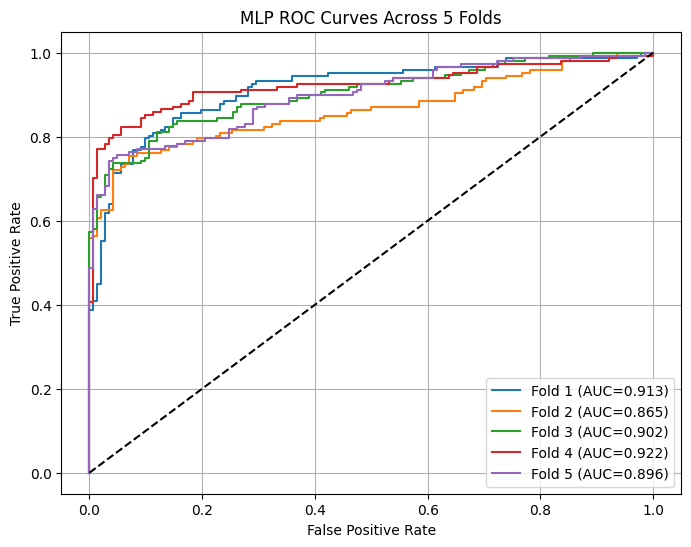

In [5]:

plt.figure(figsize=(8, 6))
for fold, fpr, tpr, auc_val in roc_curves:
    plt.plot(fpr, tpr, label=f"Fold {fold} (AUC={auc_val:.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MLP ROC Curves Across 5 Folds")
plt.legend()
plt.grid(True)
plt.show()


In [6]:

results_df.to_csv("MLP_fold_results.csv", index=False)
summary_df.to_csv("MLP_summary_results.csv", index=False)

print("Saved:")
print("- MLP_fold_results.csv")
print("- MLP_summary_results.csv")


Saved:
- MLP_fold_results.csv
- MLP_summary_results.csv


                                              smiles  y_prob       QED
7    O=[N+]([O-])c1ccc(CNC2=NN=S(=O)(O)c3ccccc32)cc1     1.0  0.660667
4  Cc1cc(S(=O)(=O)Nc2nnc3c(C(F)(F)F)cc(Cl)cn23)c(...     1.0  0.570228


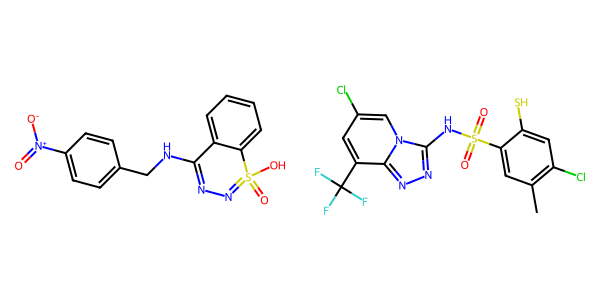

In [7]:
# ================================
# MLP FINAL PIPELINE (TOP-2 + DOCKING)
# ================================

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
from rdkit.Chem import Lipinski, Crippen, QED
from sklearn.model_selection import train_test_split

# Rebuild test SMILES for the last fold
_, test_idx_local = train_test_split(
    temp_idx,
    test_size=VAL_SIZE_WITHIN_TEMP,
    stratify=y_temp,
    random_state=SEED + fold
)

smiles_test = df.iloc[test_idx_local]["smiles"].reset_index(drop=True)

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.5).astype(int)

df_pred = pd.DataFrame({
    "smiles": smiles_test,
    "y_true": y_test,
    "y_pred": y_pred,
    "y_prob": y_prob
})

top_df = df_pred.sort_values(by="y_prob", ascending=False).head(10)

def compute_desc(sm):
    mol = Chem.MolFromSmiles(sm)
    if mol is None:
        return None
    return {
        "MW": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "TPSA": Descriptors.TPSA(mol),
        "RotBonds": Lipinski.NumRotatableBonds(mol),
        "QED": QED.qed(mol)
    }

desc_list = []
for _, row in top_df.iterrows():
    d = compute_desc(row["smiles"])
    if d:
        d.update(row.to_dict())
        desc_list.append(d)

df_desc = pd.DataFrame(desc_list)

df_desc["Lipinski"] = (
    (df_desc["MW"] <= 500) &
    (df_desc["LogP"] <= 5) &
    (df_desc["HBD"] <= 5) &
    (df_desc["HBA"] <= 10)
)

filtered_df = df_desc[df_desc["Lipinski"] == True]

final_df = filtered_df.sort_values(by=["QED", "y_prob"], ascending=False).head(2)

print(final_df[["smiles", "y_prob", "QED"]])

final_df["smiles"].to_csv("MLP_docking_input.smi", index=False, header=False)

mols = [Chem.MolFromSmiles(sm) for sm in final_df["smiles"]]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=2,
    subImgSize=(300,300)
)

display(img)



MLP TOP 10 CANDIDATES:


,MW,LogP,HBD,HBA,TPSA,RotBonds,QED,smiles,y_true,y_pred,y_prob,Lipinski
0,1501.620,-6.64700,20,35,550.89,17,0.036566,CC1OC(OC2C(O)COC(OC3C(C)OC(OC4C(OC(=O)C56CCC(C)(C)CC5C5=CCC7C8(C)CC(O)C(OC9OC(CO)C(O)C(OC%10OC(CO)C(O)C(O)C%10O)C9O)C(C)(CO)C8CCC7(C)C5(C)CC6)OCC(O)C4O)C(O)C3OC3OCC(O)C(O)C3O)C2O)C(O)C(O)C1O,1,1,1.0,False
1,769.945,9.34202,1,8,161.97,15,0.046416,C#[N+]CCOP(=O)(OCC1OC(n2cc(C)c(=O)[nH]c2=O)CC1N=[N+]=[N-])OC1CCC2(C)C(=CCC3C2CCC2(C)C(C(C)CCCC(C)C)CCC32)C1,1,1,1.0,False
2,631.631,6.46344,6,13,281.19,9,0.066941,Cc1cc(N=Nc2c(N)c(C)cc(N=Nc3ccc(C(N)=O)cc3)c2N)ccc1N=Nc1cc(C(=O)O)c(O)c(S(=O)(=O)O)c1,1,1,1.0,False
3,525.459,1.46432,4,9,232.71,10,0.114540,COC(=O)C(Cc1ccccc1)NP(=O)(O)OCC1OC(n2cc(C)c(=O)[nH]c2=O)CC1N=[N+]=[N-].N,1,1,1.0,False
4,457.286,4.45282,2,5,76.36,3,0.570228,Cc1cc(S(=O)(=O)Nc2nnc3c(C(F)(F)F)cc(Cl)cn23)c(S)cc1Cl,1,1,1.0,True
5,581.670,3.47352,2,8,176.45,5,0.231378,Cc1cn(C2CC(N=[N+]=[N-])C(COC(=O)C3CCC4C5CCC6=CC(=O)CCC6(C)C5C(O)CC34C)O2)c(=O)[nH]c1=O,1,1,1.0,False
6,995.275,10.70990,4,13,222.43,38,0.036306,CCCCCCCCCCCCCCCC(=O)Nc1ccn(C2CSC(COP(=O)(O)OC3CC(n4ccc(NC(=O)CCCCCCCCCCCCCCC)nc4=O)OC3CO)O2)c(=O)n1,1,1,1.0,False
7,332.341,2.35970,2,6,117.19,3,0.660667,O=[N+]([O-])c1ccc(CNC2=NN=S(=O)(O)c3ccccc32)cc1,1,1,1.0,True
8,336.844,4.78792,1,4,46.76,5,0.484283,Cc1occc1C(=S)Nc1ccc(Cl)c(C=NOC(C)C)c1,1,1,1.0,True
9,681.615,1.02120,5,10,274.31,8,0.075281,Cn1cc(NC(=O)c2cc([N+](=O)[O-])cn2C)cc1C(=O)Nc1cc(S(=O)(=O)O)c2cc(S(=O)(=O)O)cc(S(=O)(=O)O)c2c1.[NaH],1,1,1.0,False



FULL SMILES (TOP 10):
1. CC1OC(OC2C(O)COC(OC3C(C)OC(OC4C(OC(=O)C56CCC(C)(C)CC5C5=CCC7C8(C)CC(O)C(OC9OC(CO)C(O)C(OC%10OC(CO)C(O)C(O)C%10O)C9O)C(C)(CO)C8CCC7(C)C5(C)CC6)OCC(O)C4O)C(O)C3OC3OCC(O)C(O)C3O)C2O)C(O)C(O)C1O
2. C#[N+]CCOP(=O)(OCC1OC(n2cc(C)c(=O)[nH]c2=O)CC1N=[N+]=[N-])OC1CCC2(C)C(=CCC3C2CCC2(C)C(C(C)CCCC(C)C)CCC32)C1
3. Cc1cc(N=Nc2c(N)c(C)cc(N=Nc3ccc(C(N)=O)cc3)c2N)ccc1N=Nc1cc(C(=O)O)c(O)c(S(=O)(=O)O)c1
4. COC(=O)C(Cc1ccccc1)NP(=O)(O)OCC1OC(n2cc(C)c(=O)[nH]c2=O)CC1N=[N+]=[N-].N
5. Cc1cc(S(=O)(=O)Nc2nnc3c(C(F)(F)F)cc(Cl)cn23)c(S)cc1Cl
6. Cc1cn(C2CC(N=[N+]=[N-])C(COC(=O)C3CCC4C5CCC6=CC(=O)CCC6(C)C5C(O)CC34C)O2)c(=O)[nH]c1=O
7. CCCCCCCCCCCCCCCC(=O)Nc1ccn(C2CSC(COP(=O)(O)OC3CC(n4ccc(NC(=O)CCCCCCCCCCCCCCC)nc4=O)OC3CO)O2)c(=O)n1
8. O=[N+]([O-])c1ccc(CNC2=NN=S(=O)(O)c3ccccc32)cc1
9. Cc1occc1C(=S)Nc1ccc(Cl)c(C=NOC(C)C)c1
10. Cn1cc(NC(=O)c2cc([N+](=O)[O-])cn2C)cc1C(=O)Nc1cc(S(=O)(=O)O)c2cc(S(=O)(=O)O)cc(S(=O)(=O)O)c2c1.[NaH]

MLP FINAL 2 CANDIDATES:


,smiles,y_prob,QED,MW,LogP,Lipinski
7,O=[N+]([O-])c1ccc(CNC2=NN=S(=O)(O)c3ccccc32)cc1,1.0,0.660667,332.341,2.35970,True
4,Cc1cc(S(=O)(=O)Nc2nnc3c(C(F)(F)F)cc(Cl)cn23)c(S)cc1Cl,1.0,0.570228,457.286,4.45282,True



FULL SMILES (FINAL 2):
1. O=[N+]([O-])c1ccc(CNC2=NN=S(=O)(O)c3ccccc32)cc1
2. Cc1cc(S(=O)(=O)Nc2nnc3c(C(F)(F)F)cc(Cl)cn23)c(S)cc1Cl

Saved: MLP_docking_input.smi


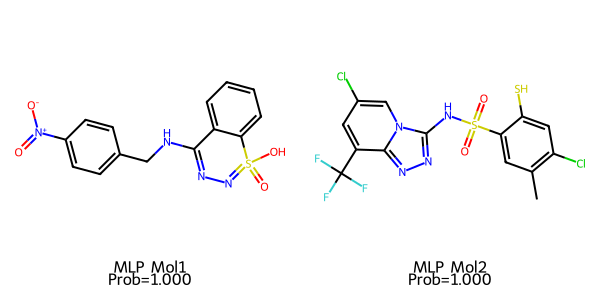

In [8]:
# ================================
# MLP FINAL PIPELINE (TOP-2 + DOCKING + FULL SMILES FIX)
# ================================

import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Draw
from rdkit.Chem import Lipinski, Crippen, QED
from sklearn.model_selection import train_test_split

# 🔴 SMILES kesilmesini engelle
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Rebuild test SMILES for the last fold
_, test_idx_local = train_test_split(
    temp_idx,
    test_size=VAL_SIZE_WITHIN_TEMP,
    stratify=y_temp,
    random_state=SEED + fold
)

smiles_test = df.iloc[test_idx_local]["smiles"].reset_index(drop=True)

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob > 0.5).astype(int)

df_pred = pd.DataFrame({
    "smiles": smiles_test,
    "y_true": y_test,
    "y_pred": y_pred,
    "y_prob": y_prob
})

top_df = df_pred.sort_values(by="y_prob", ascending=False).head(10).reset_index(drop=True)

def compute_desc(sm):
    mol = Chem.MolFromSmiles(sm)
    if mol is None:
        return None
    return {
        "MW": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "TPSA": Descriptors.TPSA(mol),
        "RotBonds": Lipinski.NumRotatableBonds(mol),
        "QED": QED.qed(mol)
    }

desc_list = []
for _, row in top_df.iterrows():
    d = compute_desc(row["smiles"])
    if d:
        d.update(row.to_dict())
        desc_list.append(d)

df_desc = pd.DataFrame(desc_list)

df_desc["Lipinski"] = (
    (df_desc["MW"] <= 500) &
    (df_desc["LogP"] <= 5) &
    (df_desc["HBD"] <= 5) &
    (df_desc["HBA"] <= 10)
)

print("\nMLP TOP 10 CANDIDATES:")
display(df_desc)

# 🔥 FULL SMILES (TOP 10)
print("\nFULL SMILES (TOP 10):")
for i, smi in enumerate(df_desc["smiles"], start=1):
    print(f"{i}. {smi}")

filtered_df = df_desc[df_desc["Lipinski"] == True].copy()

if len(filtered_df) >= 2:
    final_df = filtered_df.sort_values(by=["QED", "y_prob"], ascending=False).head(2).copy()
else:
    final_df = df_desc.sort_values(by=["QED", "y_prob"], ascending=False).head(2).copy()

print("\nMLP FINAL 2 CANDIDATES:")
display(final_df[["smiles", "y_prob", "QED", "MW", "LogP", "Lipinski"]])

# 🔥 FULL SMILES (FINAL 2)
print("\nFULL SMILES (FINAL 2):")
for i, smi in enumerate(final_df["smiles"], start=1):
    print(f"{i}. {smi}")

final_df["smiles"].to_csv("MLP_docking_input.smi", index=False, header=False)
print("\nSaved: MLP_docking_input.smi")

mols = [Chem.MolFromSmiles(sm) for sm in final_df["smiles"]]

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=2,
    subImgSize=(300, 300),
    legends=[
        f"MLP Mol1\nProb={final_df.iloc[0]['y_prob']:.3f}" if len(final_df) > 0 else "",
        f"MLP Mol2\nProb={final_df.iloc[1]['y_prob']:.3f}" if len(final_df) > 1 else ""
    ]
)

display(img)

In [ ]:
print("\nFINAL 2 MOLECULES:")
print(final_df)

# nicer format if you prefer:
display(final_df)

final_df = filtered_df.sort_values(by=["QED", "y_prob"], ascending=False).head(2)

# fix column order
final_df = final_df[[
    "MW", "LogP", "HBD", "HBA", "TPSA", "RotBonds",
    "QED", "smiles", "fold", "y_true", "y_pred", "y_prob", "Lipinski"
]]

print("\nFINAL 2 MOLECULES:")
display(final_df)


FINAL 2 MOLECULES:
        MW     LogP  HBD  HBA    TPSA  RotBonds       QED  \
7  332.341  2.35970    2    6  117.19         3  0.660667   
4  457.286  4.45282    2    5   76.36         3  0.570228   

                                              smiles  y_true  y_pred  y_prob  \
7    O=[N+]([O-])c1ccc(CNC2=NN=S(=O)(O)c3ccccc32)cc1       1       1     1.0   
4  Cc1cc(S(=O)(=O)Nc2nnc3c(C(F)(F)F)cc(Cl)cn23)c(...       1       1     1.0   

   Lipinski  
7      True  
4      True  


,MW,LogP,HBD,HBA,TPSA,RotBonds,QED,smiles,y_true,y_pred,y_prob,Lipinski
7,332.341,2.35970,2,6,117.19,3,0.660667,O=[N+]([O-])c1ccc(CNC2=NN=S(=O)(O)c3ccccc32)cc1,1,1,1.0,True
4,457.286,4.45282,2,5,76.36,3,0.570228,Cc1cc(S(=O)(=O)Nc2nnc3c(C(F)(F)F)cc(Cl)cn23)c(...,1,1,1.0,True


KeyError: "['fold'] not in index"